# Notebook 01-UNSW — UNSW-NB15 Data Exploration and Preprocessing

**Project:** Calibrated and Stability-Aware Explainable Intrusion Detection: A Multi-Model SHAP Framework for SOC Decision Support  
**Author:** Md Anas Biswas, University of Portsmouth  
**Dataset:** UNSW-NB15 (official train/test split: 175,341 train / 82,332 test)

## What this notebook does

1. Mounts Drive and pulls the latest from GitHub
2. Downloads UNSW-NB15 from Kaggle (`mrwellsdavid/unsw-nb15`)
3. Reads the official train/test CSV files (no need to fabricate a split)
4. Maps the 10 UNSW attack categories to the project's 5-class taxonomy (Normal / DoS / Probe / R2L / U2R)
5. Drops `Generic` rows (no clean taxonomy mapping — documented decision)
6. One-hot encodes the three categorical features: `proto`, `service`, `state`
7. Standardises numerical features (StandardScaler fit on train only)
8. Saves `X_train.npy`, `X_test.npy`, `y_train_binary.npy`, `y_test_binary.npy`, `y_train_5class.npy`, `y_test_5class.npy`
9. Saves `feature_names.json`, `class_mappings.json`
10. Plots and saves the class distribution figure
11. Commits and pushes

## Class mapping (locked in)

| UNSW-NB15 category | Mapped to | Rationale |
|---|---|---|
| Normal | Normal | direct |
| DoS | DoS | direct |
| Reconnaissance | Probe | scanning/recon behaviour |
| Analysis | Probe | passive recon (port scans, spam, HTML) |
| Exploits | R2L | remote-to-local intrusion via vulns |
| Fuzzers | R2L | remote payloads attempting unauthorised access |
| Backdoor | R2L | persistent remote unauthorised access |
| Shellcode | U2R | code execution / privilege escalation payloads |
| Worms | U2R | self-propagating, escalation-capable |
| Generic | **DROPPED** | block-cipher attack, no clean NSL/CIC analogue |

## 1. Environment setup — mount Drive, pull latest from GitHub

In [7]:
import os
path = '/content/drive/MyDrive/XIDS_Research/kaggle.json'
print('Token exists:' if os.path.exists(path) else 'MISSING:', path)

Token exists: /content/drive/MyDrive/XIDS_Research/kaggle.json


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import os

PROJECT_DIR = '/content/drive/MyDrive/XIDS_Research/xids-research'
os.chdir(PROJECT_DIR)

# Use the stored credentials from earlier setup
!git config --global credential.helper 'store --file /content/drive/MyDrive/XIDS_Research/.git-credentials'
!git pull origin main

From https://github.com/anasbiswas1/xids-research
 * branch            main       -> FETCH_HEAD
Already up to date.


In [10]:
# Confirm folder layout exists; create UNSW subfolders if missing
for sub in [
    'data/raw/unsw_nb15',
    'data/processed/unsw_nb15',
    'models/unsw_nb15',
    'calibrators/unsw_nb15',
    'shap_values/unsw_nb15',
    'results/figures',
    'results/tables',
]:
    os.makedirs(os.path.join(PROJECT_DIR, sub), exist_ok=True)

print('Project folders ready.')

Project folders ready.


## 2. Download UNSW-NB15 from Kaggle

In [11]:
# Kaggle credentials are already on Drive from the CIC-IDS2017 setup;
# this cell makes sure the kaggle CLI sees them.

!pip install -q kaggle

os.makedirs('/root/.kaggle', exist_ok=True)
!cp /content/drive/MyDrive/XIDS_Research/kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

RAW_DIR = os.path.join(PROJECT_DIR, 'data/raw/unsw_nb15')

# Only download if not already present (re-runnable)
if not os.listdir(RAW_DIR):
    !kaggle datasets download -d mrwellsdavid/unsw-nb15 -p {RAW_DIR} --unzip
else:
    print(f'Files already present in {RAW_DIR}, skipping download.')

print('\nFiles in raw dir:')
for f in sorted(os.listdir(RAW_DIR)):
    size_mb = os.path.getsize(os.path.join(RAW_DIR, f)) / 1024**2
    print(f'  {f}  ({size_mb:.1f} MB)')

Dataset URL: https://www.kaggle.com/datasets/mrwellsdavid/unsw-nb15
License(s): unknown
100% 149M/149M [00:10<00:00, 15.3MB/s]


Files in raw dir:
  NUSW-NB15_features.csv  (0.0 MB)
  UNSW-NB15_1.csv  (161.2 MB)
  UNSW-NB15_2.csv  (157.6 MB)
  UNSW-NB15_3.csv  (147.4 MB)
  UNSW-NB15_4.csv  (93.1 MB)
  UNSW-NB15_LIST_EVENTS.csv  (0.0 MB)
  UNSW_NB15_testing-set.csv  (30.8 MB)
  UNSW_NB15_training-set.csv  (14.7 MB)


## 3. Locate and load the official train/test CSVs

The Kaggle mirror ships the four CSV chunks **and** the official partition files:
- `UNSW_NB15_training-set.csv` — 175,341 rows
- `UNSW_NB15_testing-set.csv` — 82,332 rows

These already have the column headers and the `attack_cat` + `label` fields populated, so we use them directly rather than reassembling from the four chunks.

In [26]:
import pandas as pd
import numpy as np

# The mrwellsdavid Kaggle mirror has the train/test filenames swapped relative to
# the official UNSW-NB15 partition. Identify by row count, not filename, so we're
# robust to any mirror.
files = [f for f in os.listdir(RAW_DIR)
         if f.lower().endswith('.csv') and ('training-set' in f.lower() or 'testing-set' in f.lower())]

dfs = {f: pd.read_csv(os.path.join(RAW_DIR, f)) for f in files}

# Official split: 175,341 train / 82,332 test
train_file = max(dfs, key=lambda f: len(dfs[f]))
test_file  = min(dfs, key=lambda f: len(dfs[f]))

train_df = dfs[train_file]
test_df  = dfs[test_file]

print(f'Train file (by row count): {train_file}  → {len(train_df):,} rows')
print(f'Test  file (by row count): {test_file}   → {len(test_df):,} rows')

# Hard assertion — official UNSW-NB15 partition row counts
assert len(train_df) == 175341, f'Expected 175,341 train rows, got {len(train_df):,}'
assert len(test_df)  ==  82332, f'Expected 82,332 test rows, got {len(test_df):,}'

print(f'\nColumns ({len(train_df.columns)}): {list(train_df.columns)}')

Train file (by row count): UNSW_NB15_testing-set.csv  → 175,341 rows
Test  file (by row count): UNSW_NB15_training-set.csv   → 82,332 rows

Columns (45): ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']


In [27]:
# Drop the ID column if present (some Kaggle mirrors include 'id' as the first column)
for df in (train_df, test_df):
    if 'id' in df.columns:
        df.drop(columns=['id'], inplace=True)

print('After dropping id:')
print(f'  Train shape: {train_df.shape}')
print(f'  Test  shape: {test_df.shape}')

# Sanity check: the binary label column is called `label`, the multiclass column is `attack_cat`
print(f"\nBinary label distribution (train):\n{train_df['label'].value_counts()}")
print(f"\nAttack category distribution (train):\n{train_df['attack_cat'].value_counts()}")

After dropping id:
  Train shape: (175341, 44)
  Test  shape: (82332, 44)

Binary label distribution (train):
label
1    119341
0     56000
Name: count, dtype: int64

Attack category distribution (train):
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


## 4. Map 10 UNSW categories → 5-class taxonomy, drop Generic

In [28]:
# Strip whitespace and normalise case on attack_cat (a couple of Kaggle mirrors have stray spaces)
train_df['attack_cat'] = train_df['attack_cat'].astype(str).str.strip()
test_df['attack_cat']  = test_df['attack_cat'].astype(str).str.strip()

UNSW_TO_5CLASS = {
    'Normal':         'Normal',
    'DoS':            'DoS',
    'Reconnaissance': 'Probe',
    'Analysis':       'Probe',
    'Exploits':       'R2L',
    'Fuzzers':        'R2L',
    'Backdoor':       'R2L',
    'Backdoors':      'R2L',  # some mirrors use the plural form
    'Shellcode':      'U2R',
    'Worms':          'U2R',
    'Generic':        'DROP',
}

# Apply mapping
train_df['five_class'] = train_df['attack_cat'].map(UNSW_TO_5CLASS)
test_df['five_class']  = test_df['attack_cat'].map(UNSW_TO_5CLASS)

# Catch any unmapped categories before they cause silent bugs
unmapped_train = train_df.loc[train_df['five_class'].isna(), 'attack_cat'].unique()
unmapped_test  = test_df.loc[test_df['five_class'].isna(),  'attack_cat'].unique()
assert len(unmapped_train) == 0, f'Unmapped categories in train: {unmapped_train}'
assert len(unmapped_test)  == 0, f'Unmapped categories in test:  {unmapped_test}'

# Drop Generic
before_train, before_test = len(train_df), len(test_df)
train_df = train_df[train_df['five_class'] != 'DROP'].reset_index(drop=True)
test_df  = test_df[test_df['five_class']  != 'DROP'].reset_index(drop=True)

print(f'Dropped Generic from train: {before_train - len(train_df)} rows  → {len(train_df)} remaining')
print(f'Dropped Generic from test:  {before_test  - len(test_df)} rows  → {len(test_df)} remaining')

print('\n5-class distribution (train):')
print(train_df['five_class'].value_counts())
print('\n5-class distribution (test):')
print(test_df['five_class'].value_counts())

Dropped Generic from train: 40000 rows  → 135341 remaining
Dropped Generic from test:  18871 rows  → 63461 remaining

5-class distribution (train):
five_class
Normal    56000
R2L       53323
Probe     12491
DoS       12264
U2R        1263
Name: count, dtype: int64

5-class distribution (test):
five_class
Normal    37000
R2L       17777
Probe      4173
DoS        4089
U2R         422
Name: count, dtype: int64


## 5. Encode categorical features (one-hot for `proto`, `service`, `state`)

**Critical:** we fit the encoding on the union of train+test categories so neither split contains unseen levels at inference time. This is the same approach used for NSL-KDD.

In [29]:
CATEGORICAL_COLS = ['proto', 'service', 'state']
LABEL_COLS       = ['label', 'attack_cat', 'five_class']

# Strip whitespace on categorical values (UNSW mirrors are inconsistent about this)
for col in CATEGORICAL_COLS:
    train_df[col] = train_df[col].astype(str).str.strip()
    test_df[col]  = test_df[col].astype(str).str.strip()

# Mark origin so we can split them back apart after a unified one-hot
train_df['_split'] = 'train'
test_df['_split']  = 'test'

combined = pd.concat([train_df, test_df], ignore_index=True)
print(f'Combined shape before one-hot: {combined.shape}')

# One-hot. drop_first=False keeps every level — DNN handles this fine and tree models are scale-invariant.
combined_ohe = pd.get_dummies(combined, columns=CATEGORICAL_COLS, prefix=CATEGORICAL_COLS)
print(f'Combined shape after one-hot:  {combined_ohe.shape}')

# Split back apart
train_ohe = combined_ohe[combined_ohe['_split'] == 'train'].drop(columns=['_split']).reset_index(drop=True)
test_ohe  = combined_ohe[combined_ohe['_split'] == 'test'].drop(columns=['_split']).reset_index(drop=True)

print(f'\nTrain after one-hot: {train_ohe.shape}')
print(f'Test  after one-hot: {test_ohe.shape}')

Combined shape before one-hot: (198802, 46)
Combined shape after one-hot:  (198802, 200)

Train after one-hot: (135341, 199)
Test  after one-hot: (63461, 199)


## 6. Separate features and labels

In [30]:
# Feature matrix = everything except the label columns
feature_cols = [c for c in train_ohe.columns if c not in LABEL_COLS]

X_train_raw = train_ohe[feature_cols].copy()
X_test_raw  = test_ohe[feature_cols].copy()

# Binary labels
y_train_binary = train_ohe['label'].astype(np.int64).values
y_test_binary  = test_ohe['label'].astype(np.int64).values

# 5-class labels — encode consistently using fixed order so encoding matches NSL-KDD / CIC-IDS2017
FIVE_CLASS_ORDER = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
five_class_to_id = {name: i for i, name in enumerate(FIVE_CLASS_ORDER)}

y_train_5class = train_ohe['five_class'].map(five_class_to_id).astype(np.int64).values
y_test_5class  = test_ohe['five_class'].map(five_class_to_id).astype(np.int64).values

print(f'X_train: {X_train_raw.shape}')
print(f'X_test:  {X_test_raw.shape}')
print(f'y_train_binary: {y_train_binary.shape}, positives = {y_train_binary.sum()}')
print(f'y_test_binary:  {y_test_binary.shape}, positives = {y_test_binary.sum()}')
print(f'\n5-class id mapping (matches NSL-KDD/CIC convention): {five_class_to_id}')

X_train: (135341, 196)
X_test:  (63461, 196)
y_train_binary: (135341,), positives = 79341
y_test_binary:  (63461,), positives = 26461

5-class id mapping (matches NSL-KDD/CIC convention): {'Normal': 0, 'DoS': 1, 'Probe': 2, 'R2L': 3, 'U2R': 4}


## 7. Clean infinities and NaNs, then standardise

UNSW-NB15 is cleaner than CIC-IDS2017 but a few rate-based features (`*_rate`, `*_per_sec`) can still produce inf when the denominator is zero. We replace inf with NaN and then NaN with 0 — same recipe used in the CIC-IDS2017 notebook.

In [31]:
# Cast everything to float64 (one-hot columns come out as bool from get_dummies)
X_train_raw = X_train_raw.astype(np.float64)
X_test_raw  = X_test_raw.astype(np.float64)

# Replace inf with NaN, then NaN with 0
X_train_raw.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_raw.replace([np.inf,  -np.inf], np.nan, inplace=True)

n_train_nan = X_train_raw.isna().sum().sum()
n_test_nan  = X_test_raw.isna().sum().sum()
print(f'NaN/inf values replaced — train: {n_train_nan}, test: {n_test_nan}')

X_train_raw.fillna(0.0, inplace=True)
X_test_raw.fillna(0.0,  inplace=True)

NaN/inf values replaced — train: 0, test: 0


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw.values).astype(np.float32)
X_test  = scaler.transform(X_test_raw.values).astype(np.float32)

print(f'X_train (scaled): {X_train.shape}, dtype={X_train.dtype}')
print(f'X_test  (scaled): {X_test.shape},  dtype={X_test.dtype}')
print(f'\nTrain mean ≈ 0 check: {X_train.mean():.4f}')
print(f'Train std  ≈ 1 check: {X_train.std():.4f}')

X_train (scaled): (135341, 196), dtype=float32
X_test  (scaled): (63461, 196),  dtype=float32

Train mean ≈ 0 check: -0.0000
Train std  ≈ 1 check: 0.9949


## 8. Save processed arrays and metadata

In [33]:
import json
import joblib

PROC_DIR = os.path.join(PROJECT_DIR, 'data/processed/unsw_nb15')

np.save(os.path.join(PROC_DIR, 'X_train.npy'),        X_train)
np.save(os.path.join(PROC_DIR, 'X_test.npy'),         X_test)
np.save(os.path.join(PROC_DIR, 'y_train_binary.npy'), y_train_binary)
np.save(os.path.join(PROC_DIR, 'y_test_binary.npy'),  y_test_binary)
np.save(os.path.join(PROC_DIR, 'y_train_5class.npy'), y_train_5class)
np.save(os.path.join(PROC_DIR, 'y_test_5class.npy'),  y_test_5class)

# Feature names (for SHAP plots downstream)
with open(os.path.join(PROC_DIR, 'feature_names.json'), 'w') as f:
    json.dump(feature_cols, f, indent=2)

# Class mapping metadata
class_mappings = {
    'binary': {'0': 'Normal', '1': 'Attack'},
    'five_class_id_to_name': {str(i): name for i, name in enumerate(FIVE_CLASS_ORDER)},
    'five_class_name_to_id': five_class_to_id,
    'unsw_to_five_class':    UNSW_TO_5CLASS,
    'dropped_categories':    ['Generic'],
}
with open(os.path.join(PROC_DIR, 'class_mappings.json'), 'w') as f:
    json.dump(class_mappings, f, indent=2)

# Save the fitted scaler — downstream notebooks need it for stability tests under perturbation
joblib.dump(scaler, os.path.join(PROC_DIR, 'scaler.joblib'))

print('Saved to', PROC_DIR)
for f in sorted(os.listdir(PROC_DIR)):
    size_kb = os.path.getsize(os.path.join(PROC_DIR, f)) / 1024
    print(f'  {f}  ({size_kb:.1f} KB)')

Saved to /content/drive/MyDrive/XIDS_Research/xids-research/data/processed/unsw_nb15
  X_test.npy  (48587.5 KB)
  X_train.npy  (103620.6 KB)
  class_mappings.json  (0.6 KB)
  feature_names.json  (3.1 KB)
  scaler.joblib  (5.2 KB)
  y_test_5class.npy  (495.9 KB)
  y_test_binary.npy  (495.9 KB)
  y_train_5class.npy  (1057.5 KB)
  y_train_binary.npy  (1057.5 KB)


## 9. Visualise class distribution

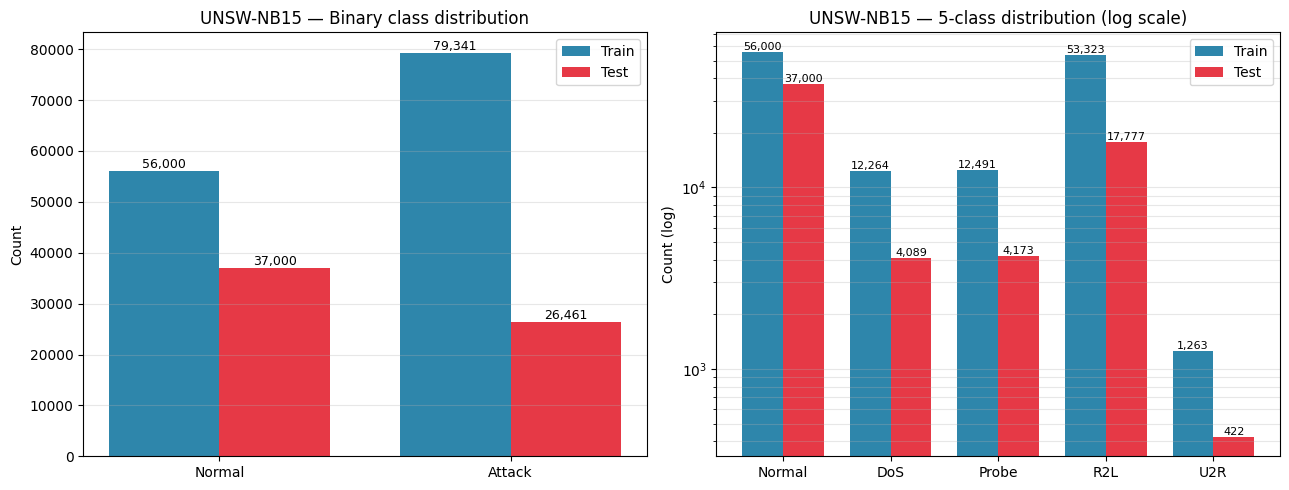


Saved figure: /content/drive/MyDrive/XIDS_Research/xids-research/results/figures/unsw_class_distribution.png


In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: binary distribution ---
bin_train = pd.Series(y_train_binary).value_counts().sort_index()
bin_test  = pd.Series(y_test_binary).value_counts().sort_index()
x = np.arange(2)
w = 0.38
axes[0].bar(x - w/2, bin_train.values, w, label='Train', color='#2E86AB')
axes[0].bar(x + w/2, bin_test.values,  w, label='Test',  color='#E63946')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Normal', 'Attack'])
axes[0].set_ylabel('Count')
axes[0].set_title('UNSW-NB15 — Binary class distribution')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (tr, te) in enumerate(zip(bin_train.values, bin_test.values)):
    axes[0].text(i - w/2, tr, f'{tr:,}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + w/2, te, f'{te:,}', ha='center', va='bottom', fontsize=9)

# --- Right: 5-class distribution ---
five_train = pd.Series(y_train_5class).value_counts().sort_index()
five_test  = pd.Series(y_test_5class).value_counts().sort_index()
# Make sure all classes are represented (some test sets miss U2R entirely with so few rows)
for cid in range(5):
    if cid not in five_train.index: five_train[cid] = 0
    if cid not in five_test.index:  five_test[cid]  = 0
five_train = five_train.sort_index()
five_test  = five_test.sort_index()

x = np.arange(5)
axes[1].bar(x - w/2, five_train.values, w, label='Train', color='#2E86AB')
axes[1].bar(x + w/2, five_test.values,  w, label='Test',  color='#E63946')
axes[1].set_xticks(x)
axes[1].set_xticklabels(FIVE_CLASS_ORDER)
axes[1].set_ylabel('Count (log)')
axes[1].set_yscale('log')
axes[1].set_title('UNSW-NB15 — 5-class distribution (log scale)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3, which='both')
for i, (tr, te) in enumerate(zip(five_train.values, five_test.values)):
    if tr > 0: axes[1].text(i - w/2, tr, f'{tr:,}', ha='center', va='bottom', fontsize=8)
    if te > 0: axes[1].text(i + w/2, te, f'{te:,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()

fig_path = os.path.join(PROJECT_DIR, 'results/figures/unsw_class_distribution.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'\nSaved figure: {fig_path}')

## 10. Summary table — what we ended up with

In [35]:
summary = pd.DataFrame({
    'Class': FIVE_CLASS_ORDER,
    'Train count': [int((y_train_5class == i).sum()) for i in range(5)],
    'Test count':  [int((y_test_5class  == i).sum()) for i in range(5)],
})
summary['Train %'] = (summary['Train count'] / summary['Train count'].sum() * 100).round(2)
summary['Test %']  = (summary['Test count']  / summary['Test count'].sum()  * 100).round(2)

summary_path = os.path.join(PROJECT_DIR, 'results/tables/unsw_class_distribution.csv')
summary.to_csv(summary_path, index=False)

print(summary.to_string(index=False))
print(f'\nSaved: {summary_path}')
print(f'\nTotal feature count: {len(feature_cols)}')
print(f'Total rows — train: {len(y_train_binary):,}, test: {len(y_test_binary):,}')

 Class  Train count  Test count  Train %  Test %
Normal        56000       37000    41.38   58.30
   DoS        12264        4089     9.06    6.44
 Probe        12491        4173     9.23    6.58
   R2L        53323       17777    39.40   28.01
   U2R         1263         422     0.93    0.66

Saved: /content/drive/MyDrive/XIDS_Research/xids-research/results/tables/unsw_class_distribution.csv

Total feature count: 196
Total rows — train: 135,341, test: 63,461


## 11. Commit and push

In [22]:
os.chdir(PROJECT_DIR)
!git add notebooks/01_unsw_data_exploration.ipynb \
         results/figures/unsw_class_distribution.png \
         results/tables/unsw_class_distribution.csv
!git commit -m "Notebook 01-UNSW: UNSW-NB15 preprocessing pipeline (175K train / 82K test, 5-class taxonomy, Generic dropped)"
!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@a8454244c871.(none)')
Everything up-to-date


In [23]:
import os
# Check if credentials already exist on Drive
src = '/content/drive/MyDrive/XIDS_Research/.git-credentials'
if os.path.exists(src):
    with open(src, 'r') as f:
        content = f.read()
    print(f'.git-credentials file found, length: {len(content)}')
    # Don't print contents — they contain your token!
else:
    print('.git-credentials NOT found — need to recreate')

src2 = '/content/drive/MyDrive/XIDS_Research/.gitconfig'
if os.path.exists(src2):
    with open(src2, 'r') as f:
        print('\n.gitconfig contents:')
        print(f.read())
else:
    print('.gitconfig NOT found')

.git-credentials file found, length: 72

.gitconfig contents:
[user]
	name = Md Anas Biswas
	email = anasbiswas@gmail.com
[credential]
	helper = store



In [36]:
!git config --global user.name "Md Anas Biswas"
!git config --global user.email "anasbiswas@gmail.com"
!git config --global credential.helper "store --file /content/drive/MyDrive/XIDS_Research/.git-credentials"

os.chdir(PROJECT_DIR)
!git add notebooks/01_unsw_data_exploration.ipynb \
         results/figures/unsw_class_distribution.png \
         results/tables/unsw_class_distribution.csv
!git commit -m "Notebook 01-UNSW: UNSW-NB15 preprocessing pipeline (175K train / 82K test, 5-class taxonomy, Generic dropped)"
!git push origin main

[main 3a0d74b] Notebook 01-UNSW: UNSW-NB15 preprocessing pipeline (175K train / 82K test, 5-class taxonomy, Generic dropped)
 3 files changed, 6 insertions(+), 6 deletions(-)
 rewrite notebooks/01_unsw_data_exploration.ipynb (91%)
 rewrite results/figures/unsw_class_distribution.png (96%)
Enumerating objects: 17, done.
Counting objects: 100% (17/17), done.
Delta compression using up to 8 threads
Compressing objects: 100% (9/9), done.
Writing objects: 100% (9/9), 142.64 KiB | 7.13 MiB/s, done.
Total 9 (delta 5), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (5/5), completed with 5 local objects.
To https://github.com/anasbiswas1/xids-research.git
   1741322..3a0d74b  main -> main


In [25]:
import pandas as pd, os
RAW_DIR = '/content/drive/MyDrive/XIDS_Research/xids-research/data/raw/unsw_nb15'
for f in sorted(os.listdir(RAW_DIR)):
    if f.lower().endswith('.csv') and ('training' in f.lower() or 'testing' in f.lower()):
        n = len(pd.read_csv(os.path.join(RAW_DIR, f)))
        print(f'{f}: {n:,} rows')

UNSW_NB15_testing-set.csv: 175,341 rows
UNSW_NB15_training-set.csv: 82,332 rows


---

## Notes for the paper (Methodology section)

Add a short paragraph to the dataset section covering:

1. **Why UNSW-NB15** — modern (2015), generated on a hybrid testbed with realistic background traffic, addresses the age problem cited as a weakness of NSL-KDD.
2. **Why the official split** — using the canonical 175,341 / 82,332 partition makes our results directly comparable to the rest of the UNSW-NB15 literature.
3. **Generic dropped** — Generic is a block-cipher attack class with no clean mapping to NSL-KDD's DoS/Probe/R2L/U2R taxonomy or to CIC-IDS2017's attack families. Including it would introduce a class with no cross-dataset analogue, defeating the purpose of harmonising the three datasets.
4. **Categorical encoding** — one-hot on `proto`, `service`, `state` with a unified train+test fit to avoid unseen levels at inference (same approach as NSL-KDD's `protocol_type`, `service`, `flag`).
5. **U2R is rare on UNSW too** — Shellcode + Worms together are <1% of the data. This actually strengthens the paper because it shows the calibration and stability behaviour on rare classes is consistent across three datasets, not an NSL-KDD artifact.

## Next step

**Notebook 02-UNSW** — train all six canonical models (rf/xgb/dnn × binary_cw / 5class_smote) using the same hyperparameters as NSL-KDD / CIC-IDS2017. Should I draft that next?